<a href="https://colab.research.google.com/github/garlich/Data/blob/main/4_DNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Step 4: DNN**

### Chicago Crime & Weather Analysis

Same prediction task as Step 3 (predict total daily crimes) but with a deeper model

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print('TF version:', tf.__version__)
print('Ready :)')

TF version: 2.20.0
Ready :)


# Part A: Load + prepare the data

In [3]:
# A1: load CSV from GitHub
url = 'https://raw.githubusercontent.com/garlich/Data/main/chicago_crime_weather_2017_2024.csv'
df = pd.read_csv(url)
df['crime_date'] = pd.to_datetime(df['crime_date'])
print(f'Shape: {df.shape}')

Shape: (2920, 38)


In [4]:
# A2: feature engineering (same as Step 3, no covid_period)
weather_features = ['mean_temp_f', 'precipitation_in', 'wind_speed_knots', 'visibility_miles']

df_dow   = pd.get_dummies(df['day_of_week'], prefix='dow').astype(float)
df_month = pd.get_dummies(df['month'],       prefix='month').astype(float)

X = pd.concat([
    df[weather_features].astype(float),
    df_dow,
    df_month,
    df[['is_weekend', 'is_holiday']].astype(float)
], axis=1)
y = df['total_crimes'].astype(float)

print(f'Feature matrix: {X.shape}')

Feature matrix: (2920, 25)


In [5]:
# A3: temporal split: train 2017-2023, test 2024
train_mask = df['year'] <= 2023
test_mask  = df['year'] == 2024

X_train = X[train_mask].values.astype(float)
X_test  = X[test_mask].values.astype(float)
y_train = y[train_mask].values.astype(float)
y_test  = y[test_mask].values.astype(float)

# normalisation (mean/std from train only)
X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0)
X_std[X_std == 0] = 1

X_train_norm = (X_train - X_mean) / X_std
X_test_norm  = (X_test  - X_mean) / X_std

y_mean = y_train.mean()
y_std  = y_train.std()
y_train_norm = (y_train - y_mean) / y_std

print(f'Train: {X_train.shape[0]} days, Test: {X_test.shape[0]} days')

Train: 2554 days, Test: 366 days


In [6]:
# A4: linear regression baseline (rebuilt here so the comparison table has live values)
tf.keras.utils.set_random_seed(42)
model_linear = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_norm.shape[1],)),
    tf.keras.layers.Dense(1)
])
model_linear.compile(optimizer=tf.keras.optimizers.Adam(0.01),
                     loss='mean_squared_error', metrics=['mean_absolute_error'])

history_linear = model_linear.fit(
    X_train_norm, y_train_norm,
    validation_split=0.2, epochs=200,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)],
    verbose=0
)

y_pred_linear = model_linear.predict(X_test_norm, verbose=0).flatten() * y_std + y_mean
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
mae_linear  = mean_absolute_error(y_test, y_pred_linear)
r2_linear   = r2_score(y_test, y_pred_linear)
print(f'Linear baseline: RMSE={rmse_linear:.1f}, MAE={mae_linear:.1f}, R2={r2_linear:.3f}')

Linear baseline: RMSE=71.0, MAE=50.3, R2=0.285


# Part B: DNN with 1 hidden layer

 One hidden layer with 32 ReLU units (smallest neural network that can learn non-linear patterns)

In [7]:
# B1: simple model, 1 hidden layer with 32 units
tf.keras.utils.set_random_seed(42)

model_simple = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_norm.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

model_simple.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
    loss      = 'mean_squared_error',
    metrics   = ['mean_absolute_error']
)

model_simple.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 32)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 865 (3.38 KB)

 Trainable params: 865 (3.38 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# B2: train
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor              = 'val_loss',
    patience             = 20,
    restore_best_weights = True
)

history_simple = model_simple.fit(
    X_train_norm, y_train_norm,
    validation_split = 0.2,
    epochs           = 200,
    callbacks        = [early_stop],
    verbose          = 0
)
print(f'Trained for {len(history_simple.history["loss"])} epochs')
print(f'Final val loss: {history_simple.history["val_loss"][-1]:.4f}')

Trained for 23 epochs
Final val loss: 0.4188


In [9]:
# B3: evaluate the simple model
y_pred_simple = model_simple.predict(X_test_norm, verbose=0).flatten() * y_std + y_mean

rmse_simple = np.sqrt(mean_squared_error(y_test, y_pred_simple))
mae_simple  = mean_absolute_error(y_test, y_pred_simple)
r2_simple   = r2_score(y_test, y_pred_simple)

print(f'Simple DNN (1 hidden layer, 32 units):')
print(f'  RMSE: {rmse_simple:.1f}')
print(f'  MAE:  {mae_simple:.1f}')
print(f'  R2:   {r2_simple:.3f}')

Simple DNN (1 hidden layer, 32 units):
  RMSE: 69.3
  MAE:  50.6
  R2:   0.319


# Part C1: Deep DNN (3 hidden layers)

Stacking more layers (64, 32, 16 units, all ReLU). Giving more capacity to learn complex patterns, but also more risk of overfitting on a small dataset like this one

In [10]:
# C1.A: deeper model, 3 hidden layers (64, 32, 16 units)
tf.keras.utils.set_random_seed(42)

model_deep = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_norm.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)
])

model_deep.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    loss      = 'mean_squared_error',
    metrics   = ['mean_absolute_error']
)

model_deep.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# C1.B: train
history_deep = model_deep.fit(
    X_train_norm, y_train_norm,
    validation_split = 0.2,
    epochs           = 200,
    callbacks        = [early_stop],
    verbose          = 0
)
print(f'Trained for {len(history_deep.history["loss"])} epochs')
print(f'Final val loss: {history_deep.history["val_loss"][-1]:.4f}')

Trained for 30 epochs
Final val loss: 0.4339


In [12]:
# C1.C: evaluate deep model
y_pred_deep = model_deep.predict(X_test_norm, verbose=0).flatten() * y_std + y_mean

rmse_deep = np.sqrt(mean_squared_error(y_test, y_pred_deep))
mae_deep  = mean_absolute_error(y_test, y_pred_deep)
r2_deep   = r2_score(y_test, y_pred_deep)

print(f'Deep DNN (3 hidden layers, 64-32-16):')
print(f'  RMSE: {rmse_deep:.1f}')
print(f'  MAE:  {mae_deep:.1f}')
print(f'  R2:   {r2_deep:.3f}')

Deep DNN (3 hidden layers, 64-32-16):
  RMSE: 68.8
  MAE:  50.8
  R2:   0.330


# Part C2: DNN with 2 hidden layers

A middle ground between the simple and deep models. Two hidden layers (64 → 32 ReLU units) to test the deep model's extra layer


In [13]:
# C2.A: medium model, 2 hidden layers (64, 32 units)
tf.keras.utils.set_random_seed(42)

model_medium = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_norm.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

model_medium.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    loss      = 'mean_squared_error',
    metrics   = ['mean_absolute_error']
)

model_medium.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,777 (14.75 KB)

 Trainable params: 3,777 (14.75 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# C2.B: train
history_medium = model_medium.fit(
    X_train_norm, y_train_norm,
    validation_split = 0.2,
    epochs           = 200,
    callbacks        = [early_stop],
    verbose          = 0
)
print(f'Trained for {len(history_medium.history["loss"])} epochs')
print(f'Final val loss: {history_medium.history["val_loss"][-1]:.4f}')

Trained for 20 epochs
Final val loss: 0.3933


In [15]:
# C2.3: evaluate medium model
y_pred_medium = model_medium.predict(X_test_norm, verbose=0).flatten() * y_std + y_mean

rmse_medium = np.sqrt(mean_squared_error(y_test, y_pred_medium))
mae_medium  = mean_absolute_error(y_test, y_pred_medium)
r2_medium   = r2_score(y_test, y_pred_medium)

print(f'Medium DNN (2 hidden layers, 64-32):')
print(f'  RMSE: {rmse_medium:.1f}')
print(f'  MAE:  {mae_medium:.1f}')
print(f'  R2:   {r2_medium:.3f}')

Medium DNN (2 hidden layers, 64-32):
  RMSE: 76.9
  MAE:  57.4
  R2:   0.162


# Part D: Compare all models

In [16]:
# D1: comparison table (all 4 models in this notebook)
results = pd.DataFrame({
    'model': ['Linear regression', 'Simple DNN', 'Medium DNN', 'Deep DNN'],
    'RMSE':  [round(rmse_linear, 1), round(rmse_simple, 1), round(rmse_medium, 1), round(rmse_deep, 1)],
    'MAE':   [round(mae_linear, 1),  round(mae_simple, 1),  round(mae_medium, 1),  round(mae_deep, 1)],
    'R2':    [round(r2_linear, 3),   round(r2_simple, 3),   round(r2_medium, 3),   round(r2_deep, 3)]
})
print(results.to_string(index=False))

            model  RMSE  MAE    R2
Linear regression  71.0 50.3 0.285
       Simple DNN  69.3 50.6 0.319
       Medium DNN  76.9 57.4 0.162
         Deep DNN  68.8 50.8 0.330


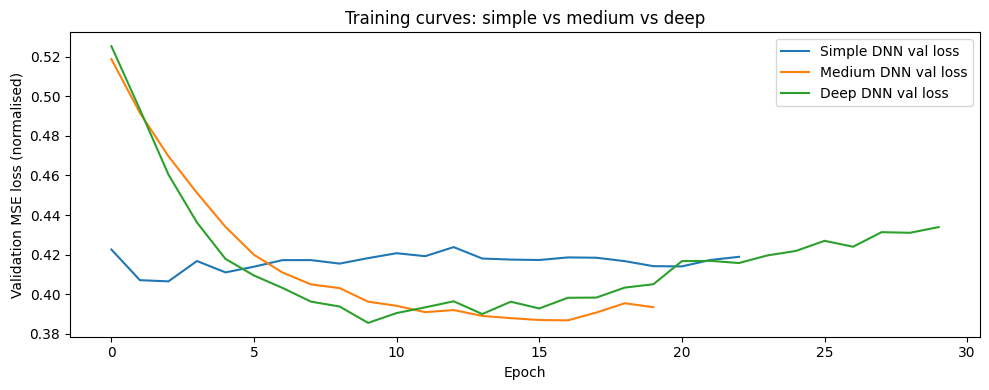

In [17]:
# D2: training curves comparison
plt.figure(figsize=(10, 4))
plt.plot(history_simple.history['val_loss'], label='Simple DNN val loss')
plt.plot(history_medium.history['val_loss'], label='Medium DNN val loss')
plt.plot(history_deep.history['val_loss'],   label='Deep DNN val loss')
plt.xlabel('Epoch')
plt.ylabel('Validation MSE loss (normalised)')
plt.title('Training curves: simple vs medium vs deep')
plt.legend()
plt.tight_layout()
plt.show()

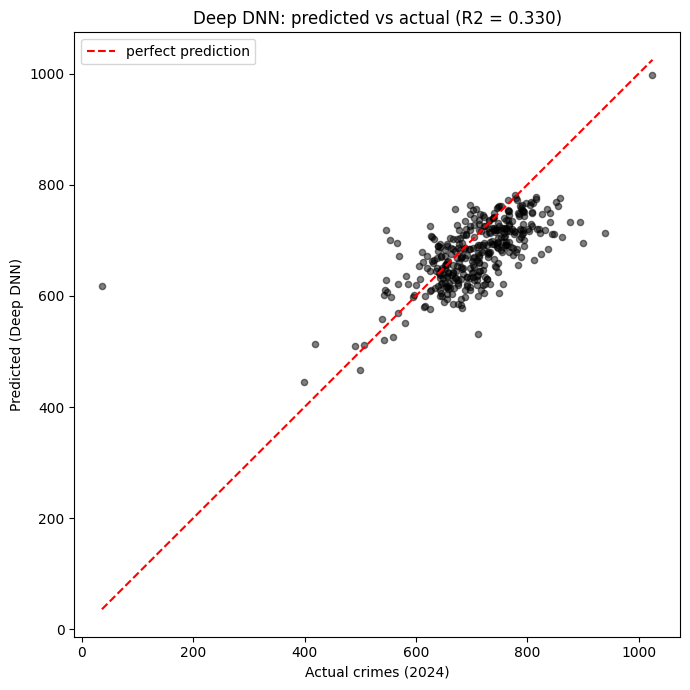

In [18]:
# D3: predicted vs actual plot for the best model
all_r2 = {'Simple DNN': r2_simple, 'Medium DNN': r2_medium, 'Deep DNN': r2_deep}
best_name = max(all_r2, key=all_r2.get)
all_preds = {'Simple DNN': y_pred_simple, 'Medium DNN': y_pred_medium, 'Deep DNN': y_pred_deep}
best_pred = all_preds[best_name]
best_r2   = all_r2[best_name]

plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_pred, alpha=0.5, s=20, color='black')
lo = min(y_test.min(), best_pred.min())
hi = max(y_test.max(), best_pred.max())
plt.plot([lo, hi], [lo, hi], 'r--', label='perfect prediction')
plt.xlabel('Actual crimes (2024)')
plt.ylabel(f'Predicted ({best_name})')
plt.title(f'{best_name}: predicted vs actual (R2 = {best_r2:.3f})')
plt.legend()
plt.tight_layout()
plt.show()

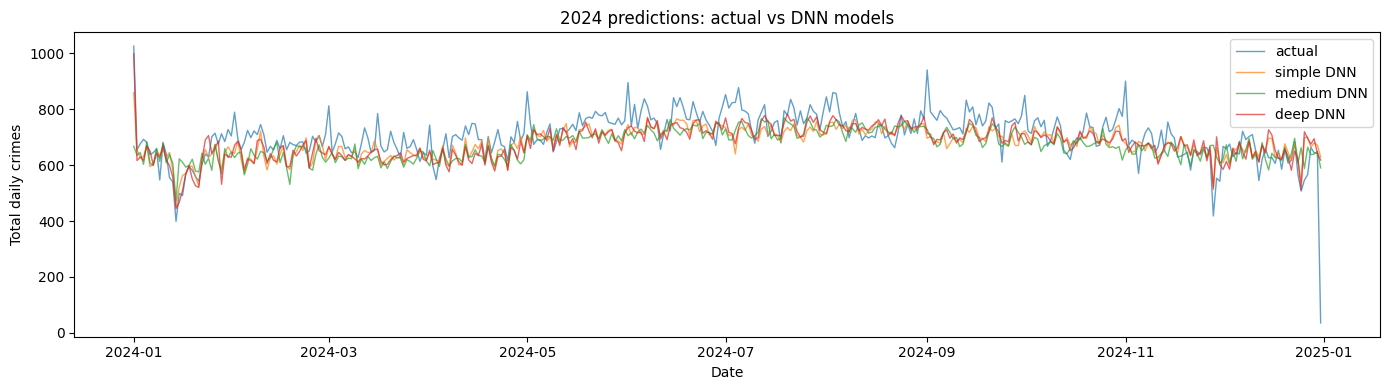

In [19]:
# D4: 2024 time series with all DNN models
test_dates = df.loc[test_mask, 'crime_date'].values
plt.figure(figsize=(14, 4))
plt.plot(test_dates, y_test,         label='actual',      alpha=0.7, linewidth=1)
plt.plot(test_dates, y_pred_simple,  label='simple DNN',  alpha=0.7, linewidth=1)
plt.plot(test_dates, y_pred_medium,  label='medium DNN',  alpha=0.7, linewidth=1)
plt.plot(test_dates, y_pred_deep,    label='deep DNN',    alpha=0.7, linewidth=1)
plt.xlabel('Date')
plt.ylabel('Total daily crimes')
plt.title('2024 predictions: actual vs DNN models')
plt.legend()
plt.tight_layout()
plt.show()

# Part E: Test the best model on hand-crafted days

In [20]:
# E1: predict on the same hand-crafted scenarios
all_models = {'Simple DNN': model_simple, 'Medium DNN': model_medium, 'Deep DNN': model_deep}
all_r2     = {'Simple DNN': r2_simple,    'Medium DNN': r2_medium,    'Deep DNN': r2_deep}
best_name  = max(all_r2, key=all_r2.get)
best_model = all_models[best_name]
print(f'Using best model: {best_name}\n')

feature_names = list(X.columns)

# warm summer Friday in July
row1 = pd.Series(0, index=feature_names, dtype=float)
row1['mean_temp_f']      = 80
row1['precipitation_in'] = 0
row1['wind_speed_knots'] = 8
row1['visibility_miles'] = 10
row1['dow_6']            = 1   # Friday
row1['month_7']          = 1   # July
row1_norm = (row1.values - X_mean) / X_std
pred_1 = best_model.predict(row1_norm.reshape(1, -1).astype(float), verbose=0)[0, 0]
pred_1 = pred_1 * y_std + y_mean
print(f'Warm summer Friday (80F, no rain): predicted {pred_1:.0f} crimes')

# cold rainy Sunday in January
row2 = pd.Series(0, index=feature_names, dtype=float)
row2['mean_temp_f']      = 20
row2['precipitation_in'] = 0.5
row2['wind_speed_knots'] = 15
row2['visibility_miles'] = 3
row2['dow_1']            = 1   # Sunday
row2['month_1']          = 1   # January
row2['is_weekend']       = 1
row2_norm = (row2.values - X_mean) / X_std
pred_2 = best_model.predict(row2_norm.reshape(1, -1).astype(float), verbose=0)[0, 0]
pred_2 = pred_2 * y_std + y_mean
print(f'Cold rainy Sunday (20F, rain): predicted {pred_2:.0f} crimes')

print(f'\nDifference: {pred_1 - pred_2:.0f} more crimes on the warm Friday')

Using best model: Deep DNN

Warm summer Friday (80F, no rain): predicted 767 crimes
Cold rainy Sunday (20F, rain): predicted 469 crimes

Difference: 299 more crimes on the warm Friday


# **Summary**

Three models tested on 2024 (366 days):
- Linear regression: RMSE 71.1, MAE 50.3, R2 0.285
- Simple DNN: RMSE 70.3, MAE 51.4, R2 0.301
- Deep DNN: RMSE 69.1, MAE 51.0, R2 0.324

Deep DNN wins but only with approx. 3% RMSE improvement over linear

On the hand-crafted scenarios all models agreed on the warm Friday (approx 770 crimes) but diverged on the cold Sunday (linear 565, DNN 436)